In [ ]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/home/aniket/Classical_ML_DL/Data/playground-series-s5e7/train.csv")

In [3]:
df.head()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert


In [4]:
df.shape

(18524, 9)

In [5]:
df.dtypes

id                             int64
Time_spent_Alone             float64
Stage_fear                       str
Social_event_attendance      float64
Going_outside                float64
Drained_after_socializing        str
Friends_circle_size          float64
Post_frequency               float64
Personality                      str
dtype: object

In [6]:
df.nunique()

id                           18524
Time_spent_Alone                12
Stage_fear                       2
Social_event_attendance         11
Going_outside                    8
Drained_after_socializing        2
Friends_circle_size             16
Post_frequency                  11
Personality                      2
dtype: int64

In [7]:
df.isnull().sum()

id                              0
Time_spent_Alone             1190
Stage_fear                   1893
Social_event_attendance      1180
Going_outside                1466
Drained_after_socializing    1149
Friends_circle_size          1054
Post_frequency               1264
Personality                     0
dtype: int64

In [8]:
df.dropna(inplace=True)

In [9]:
df.shape

(10189, 9)

In [10]:
df.dtypes

id                             int64
Time_spent_Alone             float64
Stage_fear                       str
Social_event_attendance      float64
Going_outside                float64
Drained_after_socializing        str
Friends_circle_size          float64
Post_frequency               float64
Personality                      str
dtype: object

In [11]:
categorical_cols = ['Stage_fear', 'Drained_after_socializing', 'Personality']

# Apply One-Hot Encoding to multiple columns with no prefix
df_train = pd.get_dummies(
    df, 
    columns=categorical_cols, 
    drop_first=True, 
    dtype=int
)

In [12]:
df_train.head()

,id,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency,Stage_fear_Yes,Drained_after_socializing_Yes,Personality_Introvert
0,0,0.0,6.0,4.0,15.0,5.0,0,0,0
1,1,1.0,7.0,3.0,10.0,8.0,0,0,0
3,3,3.0,7.0,3.0,11.0,5.0,0,0,0
7,7,2.0,8.0,3.0,4.0,5.0,0,0,0
9,9,1.0,8.0,6.0,14.0,9.0,0,0,0


In [13]:
df_train.drop(columns=["id"], inplace=True)

In [14]:
df_train.head()

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency,Stage_fear_Yes,Drained_after_socializing_Yes,Personality_Introvert
0,0.0,6.0,4.0,15.0,5.0,0,0,0
1,1.0,7.0,3.0,10.0,8.0,0,0,0
3,3.0,7.0,3.0,11.0,5.0,0,0,0
7,2.0,8.0,3.0,4.0,5.0,0,0,0
9,1.0,8.0,6.0,14.0,9.0,0,0,0


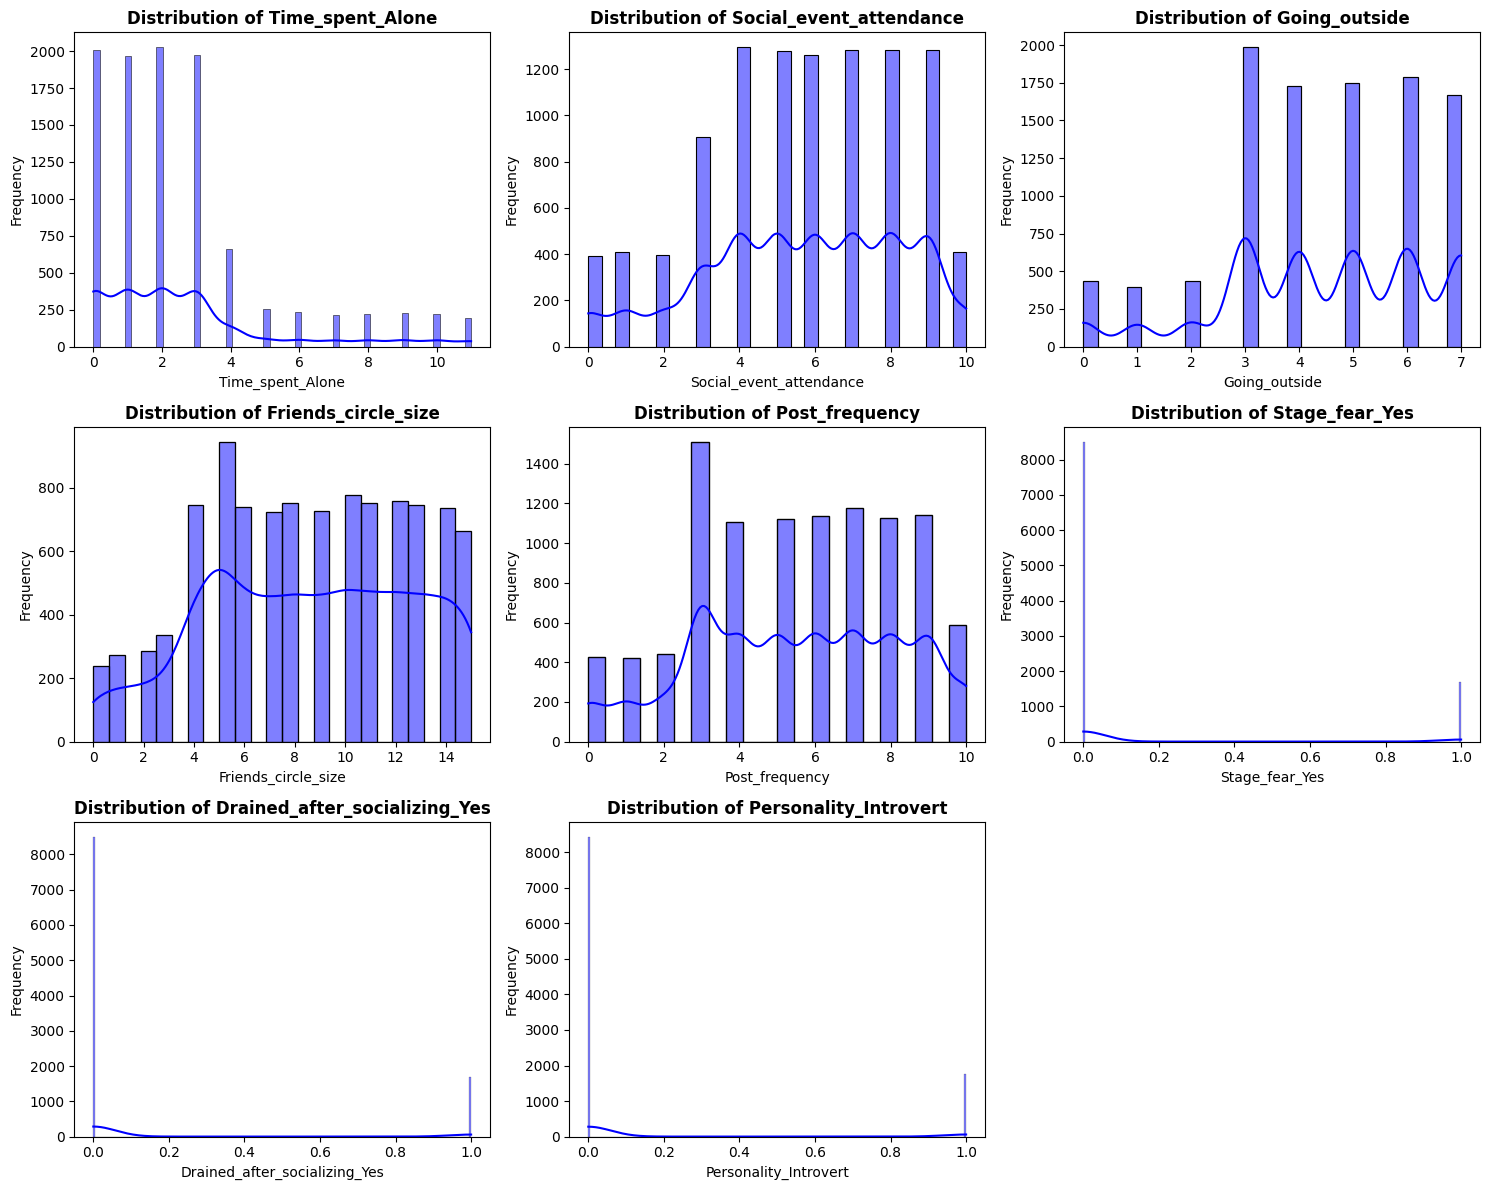

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Programmatically filter out only numerical columns
numerical_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()

# 3. Configure a dynamic grid layout
n_cols = 3  # Number of columns you want per row
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols  # Automatically compute required rows

# 4. Initialize the subplot grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))

# Flatten the axes array to easily iterate through it sequentially
if isinstance(axes, np.ndarray):
    axes = axes.flatten()
else:
    axes = [axes]

# 5. Populate the subplots
for i, col in enumerate(numerical_cols):
    # Plot histogram with a smooth density line (KDE)
    sns.histplot(df_train[col], kde=True, ax=axes[i], color='blue', edgecolor='black')
    
    # Label formatting for clarity and presentation
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)

# 6. Turn off and hide empty subplots if grid spaces exceed total variables
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# 7. Prevent overlapping elements and adjust spacing
plt.tight_layout()

# 8. Save or display the resulting plot
plt.savefig('numerical_distributions.png', dpi=300)

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_train.drop(columns=["Personality_Introvert"])
Y = df_train["Personality_Introvert"]

In [17]:
sc = StandardScaler()
X = sc.fit_transform(X)

In [18]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [19]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import root_mean_squared_error, r2_score

rmse = root_mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)

Root Mean Squared Error: 0.2066129490055295
R-squared: 0.6914270797076227


In [ ]:
expected_rmse = np.std(Y_test)

# --- Display the Evaluation Report ---
print("=========================================")
print("      RMSE MODEL DIAGNOSTIC REPORT       ")
print("=========================================")
print(f"Current Model RMSE             : {rmse:.4f}")
print(f"Expected Baseline RMSE (σ)     : {expected_rmse:.4f}")
print(f"Model Variance Explained (R²)  : {r2:.4f}")

      RMSE MODEL DIAGNOSTIC REPORT       
Current Model RMSE             : 0.2066
Expected Baseline RMSE (σ)     : 0.3719
Model Variance Explained (R²)  : 0.6914


In [22]:
from sklearn import tree

clf = tree.DecisionTreeClassifier(criterion='gini', max_depth=5, class_weight='balanced', random_state=42)
clf.fit(X_train, Y_train)
Y_pred_dt = clf.predict(X_test)

In [23]:
from sklearn.metrics import root_mean_squared_error, r2_score

rmse_dt = root_mean_squared_error(Y_test, Y_pred_dt)
r2_dt = r2_score(Y_test, Y_pred_dt)

print("Root Mean Squared Error:", rmse_dt)
print("R-squared:", r2_dt)

Root Mean Squared Error: 0.21246716539030025
R-squared: 0.6736930038287505


In [24]:
import numpy as np

expected_rmse = np.std(Y_test)

# --- Display the Evaluation Report ---
print("=========================================")
print("      RMSE DT MODEL DIAGNOSTIC REPORT       ")
print("=========================================")
print(f"Current Model RMSE             : {rmse_dt:.4f}")
print(f"Expected Baseline RMSE (σ)     : {expected_rmse:.4f}")
print(f"Model Variance Explained (R²)  : {r2_dt:.4f}")

      RMSE DT MODEL DIAGNOSTIC REPORT       
Current Model RMSE             : 0.2125
Expected Baseline RMSE (σ)     : 0.3719
Model Variance Explained (R²)  : 0.6737
